# Part A — Supervised Learning + Metrics (25 marks)

## Q1. Decision Tree on Digits + Metrics (15 marks)

**Use the digits dataset from sklearn.**

	1.	Load digits data (X, y). Split into train/test (80/20, stratified, fixed random_state).
	2.	Train a DecisionTreeClassifier (set max_depth=10, fixed random_state).
	3.	On the test set, compute and print:

    	•	accuracy
    	•	macro precision
    	•	macro recall
    	•	macro F1-score

	4.	Create a confusion matrix visualization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# 1. Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1437, 64) (1437,)
Test : (360, 64) (360,)


In [3]:
# 2. Train Decision Tree
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [4]:
#3.On the test set, compute and print:
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", acc)
print("Macro Precision:", prec)
print("Macro Recall:", rec)
print("Macro F1-score:", f1)

Accuracy: 0.8111111111111111
Macro Precision: 0.8144700459174142
Macro Recall: 0.8103582153582154
Macro F1-score: 0.8113965579020231


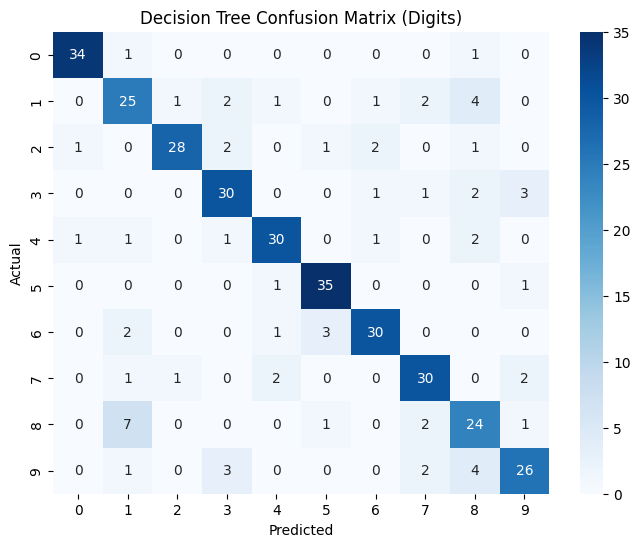

In [5]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Digits)")
plt.show()

## Q2. AdaBoost (stumps) vs Decision Tree (10 marks)

**Using the same train/test split:**

	1.	Train an AdaBoostClassifier where the base learner is a decision stump (DecisionTreeClassifier(max_depth=1)). Use n_estimators=100.
	2.	Evaluate AdaBoost test accuracy.
	3.	Print both accuracies in one line:

    	•	Decision Tree accuracy
    	•	AdaBoost accuracy

In [6]:
#1.  Train an AdaBoostClassifier where the base learner is a decision stump (DecisionTreeClassifier(max_depth=1)). Use n_estimators=100
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost with decision stumps
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [7]:
#2.Evaluate AdaBoost test accuracy.
y_pred_ada = ada.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

Accuracy: 0.8305555555555556


In [9]:
# Print both accuracies in one line
dt_acc = acc
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"Decision Tree Accuracy: {dt_acc:.4f} | AdaBoost Accuracy: {ada_acc:.4f}")

Decision Tree Accuracy: 0.8111 | AdaBoost Accuracy: 0.8306


# Part B — Cross-validation (10 marks)

## Q3. 5-Fold CV score (10 marks)

**Using digits dataset again:**

	1.	Create a 5-fold cross-validation object that keeps class balance (stratified).
	2.	Compute cross-validation accuracy for AdaBoost using cross_val_score.
	3.	Print:

    	•	all 5 scores
    	•	mean score
    	•	standard deviation

In [10]:
#1. Create a 5-fold cross-validation object that keeps class balance (stratified).
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
#2.  Compute cross-validation accuracy for AdaBoost using cross_val_score.
scores = cross_val_score(ada, X, y, cv=cv, scoring='accuracy')

In [12]:
# 3. Print results
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.83611111 0.78611111 0.7994429  0.82729805 0.79665738]
Mean Accuracy: 0.8091241101826061
Standard Deviation: 0.019169421744118353


In [15]:
#F1 score
cv_scores_f1 = cross_val_score(ada, X, y, cv=cv, scoring="f1_macro")
print("CV F1_macro scores:", cv_scores_f1)
print("Mean CV F1_macro  :", cv_scores_f1.mean())
print("Std CV F1_macro   :", cv_scores_f1.std())

CV F1_macro scores: [0.83860286 0.78191557 0.79989948 0.82960372 0.79687009]
Mean CV F1_macro  : 0.8093783461910291
Std CV F1_macro   : 0.02127744025670795


# Part C — Clustering + Evaluation (5 marks)

## Q4. KMeans + Silhouette (5 marks)

**Create a dataset using make_blobs(n_samples=400, centers=4, random_state=42).**

	1.	Scale the data.
	2.	Run KMeans(K=4).
	3.	Compute SSE and visualize the optimal K value.
	4.	Plot the clustered scatter plot (color by cluster label).

In [17]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create dataset
X, _ = make_blobs(n_samples=400, centers=4, random_state=42)

In [18]:
#1.  Scale the data.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
#2.  Run KMeans(K=4).
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

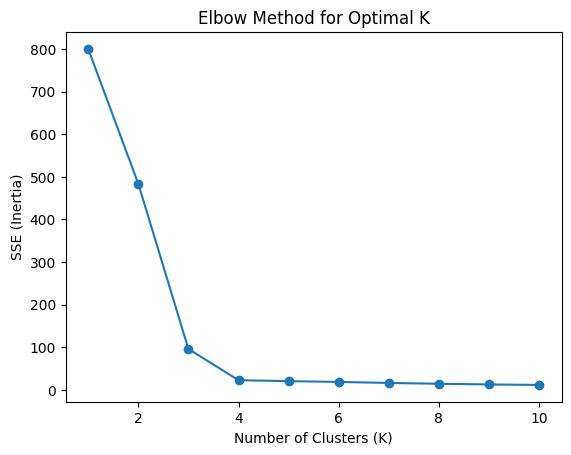

In [28]:
#3.  Compute SSE and visualize the optimal K value.
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)   # SSE (inertia)
plt.figure()
plt.plot(K, sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()

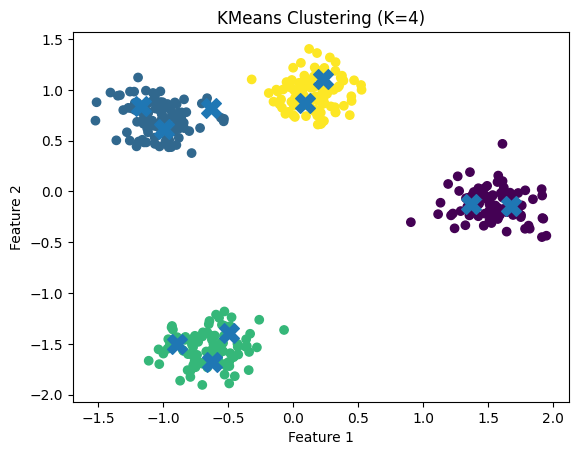

In [29]:
#4.  Plot the clustered scatter plot (color by cluster label).
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

# Plot centroids (optional but better)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title('KMeans Clustering (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()